# Exercise 2: Analyzing vegetation indices

just run ```uv sync```

## 2. Compute the Normalized Difference Vegetation Index (NDVI) of sentinel images
- Download the Sentinel-2 images from [here](https://drive.google.com/file/d/1NGfrldM4r7uC04nRgevD4DUH48Bnm72Y/view?usp=sharing).
- Place the downloaded .zip file to the same folder as this notebook

In [1]:
import zipfile
import os

with zipfile.ZipFile("images_week2.zip", 'r') as zip_ref:
    zip_ref.extractall()
    
print(os.listdir("images_week2"))

['image_2021_06', 'image_2021_02', 'image_2020_10', 'image_2021_08', 'image_2021_04']


- The zip file has 5 folders that contain files of 5 different sentinel images acquired in different timestamps. The folder names have the following structure: ***image_year_month***. Read the images using the function ***imread*** of the ***skimage*** library
- Compute NDVI of each image and save it on disk
- Visualize the NDVI image of the sentinel image taken on Aug 2021

In [2]:
# TODO: Fill the directory path where the images were uncompressed
images_path = "images_week2/"
sub_directories = ["image_2020_10", "image_2021_02", "image_2021_04", "image_2021_06", "image_2021_08"]
directories = [os.path.join(images_path, subdir) for subdir in sub_directories]

In [3]:
import numpy as np
from skimage.io import imsave, imread

# Compute NDVI of several sentinel images
for directory in directories:
    # Define the full image paths to read the Red and NIR band of each sentinel image
    band4_path = directory + "/band4.jp2" # Red
    band8_path = directory + "/band8.jp2" # Near-infrared (NIR)
    
    # Read images
    band4_array = imread(band4_path).astype(np.float32)
    band8_array = imread(band8_path).astype(np.float32)
    
    # TODO: compute NDVI indexes
    ndvi_array = (band8_array - band4_array) / (band8_array + band4_array)
    
    # Save NDVI image
    ndvi_path = directory + "/ndvi.tif".format(directory)
    imsave(ndvi_path, ndvi_array)
    print("Image saved in: " + ndvi_path)

/tmp/ipykernel_49881/4291413011.py:15: RuntimeWarning: invalid value encountered in divide
  ndvi_array = (band8_array - band4_array) / (band8_array + band4_array)


Image saved in: images_week2/image_2020_10/ndvi.tif


Image saved in: images_week2/image_2021_02/ndvi.tif


/tmp/ipykernel_49881/4291413011.py:15: RuntimeWarning: invalid value encountered in divide
  ndvi_array = (band8_array - band4_array) / (band8_array + band4_array)


Image saved in: images_week2/image_2021_04/ndvi.tif


/tmp/ipykernel_49881/4291413011.py:15: RuntimeWarning: invalid value encountered in divide
  ndvi_array = (band8_array - band4_array) / (band8_array + band4_array)


Image saved in: images_week2/image_2021_06/ndvi.tif


Image saved in: images_week2/image_2021_08/ndvi.tif


/tmp/ipykernel_49881/4291413011.py:15: RuntimeWarning: invalid value encountered in divide
  ndvi_array = (band8_array - band4_array) / (band8_array + band4_array)


Now, let's visualize the NDVI images

In [4]:
import matplotlib.pyplot as plt
from  matplotlib.colors import LinearSegmentedColormap

def plot_vegetation_index(image_arr):
    # Remove outliers
    p_min, p_max = np.percentile(image_arr[~np.isnan(image_arr)], (2, 98))
    image_arr_clipped = image_arr.clip(p_min, p_max)
    # Create a color map
    cmap_rg=LinearSegmentedColormap.from_list('rg',
                        ["red", "yellow", "green", "darkgreen"], N=256) 
    # Show image
    plt.imshow(image_arr_clipped, cmap=cmap_rg)
    plt.colorbar()

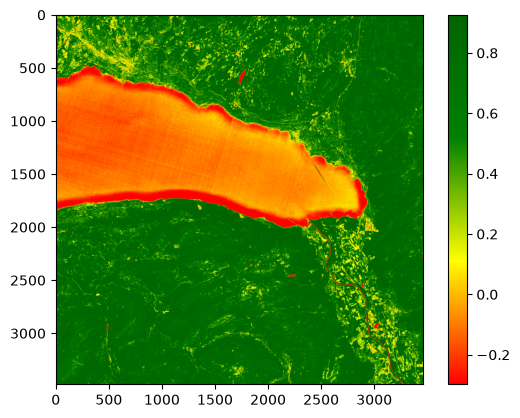

In [5]:
# TODO: Visualize the NDVI image (that you saved on disk in previous code blocks) 
#       of the sentinel image taken on Aug 2021,
#       using the function plot_vegetation_index (defined above)
plot_vegetation_index(ndvi_array)

## 3. Compute and visualize the average NDVI values of 4 regions in the 5 images provided

- Compute the average NDVI of 4 regions (defined by the bounding boxes) in the 5 images provided.
- The sentinel images were taken on Oct 2020, Feb 2021,  Apr 2021, Jun 2021, and Aug 2021.
- The bounding boxes are defined in the pixel coordinate system
- Use the function ***crop_image*** defined below to crop the regions
- Visualize the average NDVI values of the 4 regions as temporal series, using matplotlib. It can help to see the code example presented in slide 4 of the exercise 2 (available on moodle)

In [6]:
def crop_image_array(image_array, y_min, x_min, y_max, x_max):
    """
    Crop image array, delimited by a bounding box
    
    Parameters
    ==================
    
    y_min: int
        Minimum vertical coordinate of the bounding box
    x_min: int
        Minimum horizontal coordinate of the bounding box
    y_max: int
        Maximum vertical coordinate of the bounding box
    x_max: int
        Maximum horizontal coordinate of the bounding box
    
    """
    return image_array[y_min:y_max+1, x_min:x_max+1]

In [7]:
# Bounding boxes of the regions to be analyzed
bounding_boxes = {'vineyard':    {'y_min': 814, 'x_min': 1509, 'y_max': 818, 'x_max': 1513}, 
                  'trees':       {'y_min': 3173, 'x_min': 3239, 'y_max': 3177, 'x_max': 3243}, 
                  'sport_field': {'y_min': 1278, 'x_min': 2628, 'y_max': 1282, 'x_max': 2632}, 
                  'buildings':   {'y_min': 1511, 'x_min': 2794, 'y_max': 1515, 'x_max': 2798}
                 }

In [8]:
# TODO: Compute the average NDVI values 
#       of the 4 regions in the 5 images (sorted in chronological order),
#       and stored it in a dictionary with the following structure. 
#
# ndvi_values = {
#   "vineyard" : [avg_ndvi_of_region_vineyard_in_image1, 
#                 avg_ndvi_of_region_vineyard_in_image2, 
#                ..., 
#                avg_ndvi_of_region_vineyard_in_image5]
#
#   "trees" :    [avg_ndvi_of_region_trees_in_image1, 
#                 avg_ndvi_of_region_trees_in_image2, 
#                ..., 
#                avg_ndvi_of_region_trees_in_image5]
#
#   "buildings" : [avg_ndvi_on_region_buildings_in_image1, 
#                 avg_ndvi_on_region_buildings_in_image2, 
#                ..., 
#                avg_ndvi_on_region_buildings_in_image5]
#
#   "sport_field" : [avg_ndvi_on_region_sport_field_in_image1, 
#                 avg_ndvi_on_region_sport_field_in_image2, 
#                ..., 
#                avg_ndvi_on_region_sport_field_in_image5]
# }

# Create an empty dictionary
ndvi_values = {}
# Iterate over all the regions. 
# The function ".keys()" retrieves the keys of a dictionary
# In the code below bounding_boxes.keys() = ["vineyard", "trees", "buildings", "sport_field"]
for region in bounding_boxes.keys():
    ndvi_values[region] = []
    for directory in directories:
        # TODO: Read the NDVI images you saved
        ndvi_array = imread(directory + "/ndvi.tif")
        
        
        # TODO: Crop image using the bounding box of each "region" 
        #       Use the function "crop_image_array" defined above
        cropped_ndvi_array = crop_image_array(ndvi_array, 
                                             bounding_boxes[region]['y_min'], 
                                             bounding_boxes[region]['x_min'], 
                                             bounding_boxes[region]['y_max'], 
                                             bounding_boxes[region]['x_max'])
        
        
        # TODO: Compute average NDVI value for the cropped region (using np.mean)
        avg_ndvi = np.mean(cropped_ndvi_array)
        
        
        # TODO: Add the computed average NDVI value to the list ndvi_values[region]
        ndvi_values[region].append(avg_ndvi)
        

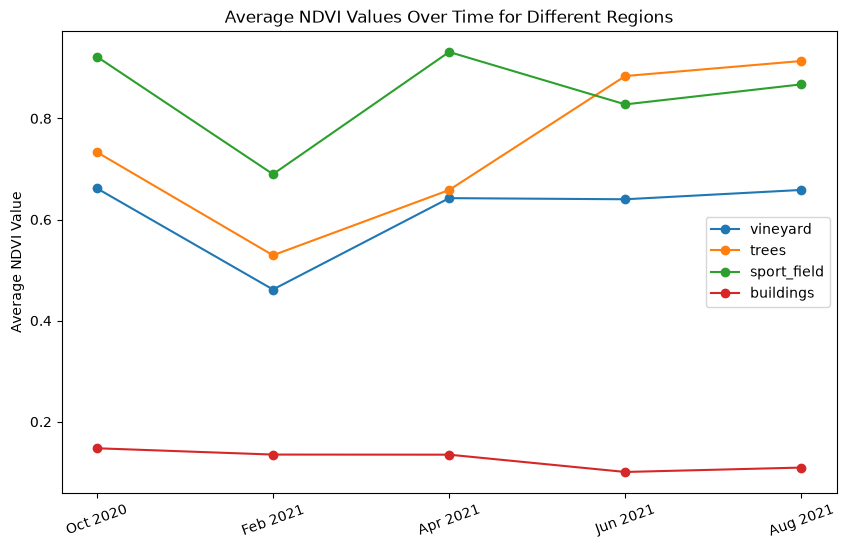

In [9]:
# TODO: Plot the computed average NDVI values of the 4 regions in the 5 images
#       follow the example of the slides of the exercise 2 (available on moodle)
plt.figure(figsize=(10, 6))
x = np.arange(5)
for region in ndvi_values.keys():
    plt.plot(x, ndvi_values[region], marker='o', label=region)
plt.xticks(x, ['Oct 2020', 'Feb 2021', 'Apr 2021', 'Jun 2021', 'Aug 2021'], rotation=20)
plt.title('Average NDVI Values Over Time for Different Regions')
plt.ylabel('Average NDVI Value')
plt.legend()
plt.show()

## 4. Answer the remaining questions of the PDF instructions file

##### Q In general, which months have the lowest and highest NDVI values?

Averaging NDVI across all 4 regions per month gives roughly: Oct 2020 ≈ 0.62, Feb 2021 ≈ 0.45, Apr 2021 ≈ 0.59, Jun 2021 ≈ 0.61, Aug 2021 ≈ 0.64. **February has the lowest NDVI** across every region (winter dormancy, deciduous vegetation without leaves, low sun angle), while **August has the highest** (peak summer canopy growth), closely followed by June and October.

##### Q Which regions have the lowest and highest NDVI values overall? Why do you think that happens?

**Buildings have by far the lowest NDVI** (~0.10-0.15 in every month), since they're impervious, non-photosynthetic surfaces. **Sport field and trees have the highest NDVI overall** (mostly 0.7-0.93), because they're the most densely vegetated, continuously green surfaces (turf grass and forest canopy) in the scene.

##### Q What can you observe when comparing NDVI values of vineyards and trees over time? Why do you think the time series of those regions differ more in certain months than in others?

Vineyard NDVI drops sharply in Feb 2021 (~0.46, dormant/pruned vines with no leaves) then jumps back up by Apr 2021 (~0.64) and stays roughly flat through Jun and Aug (~0.64) — the canopy reaches near-full leaf-out early and plateaus, partly because bare soil between the vine rows keeps NDVI capped even at full growth. Trees also dip in Feb (~0.53) but then keep climbing through the season — Apr ≈ 0.66, Jun ≈ 0.88, Aug ≈ 0.91 — since forest canopy density builds up more gradually and keeps increasing into summer, unlike the quickly-maturing, row-structured vineyard canopy. That's why the two time series diverge most in Jun/Aug: vineyards have already plateaued while trees are still thickening.